In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

crime = pd.read_csv("data/cleaned_crime_long.csv", parse_dates=["Date"])
london_monthly = crime.groupby("Date")["CrimeCount"].sum().asfreq("MS")

print("Last known month:", london_monthly.index.max().date())

final_model = SARIMAX(london_monthly, order=(1, 1, 0), seasonal_order=(1, 1, 0, 12))
fitted_final = final_model.fit(disp=False)

print("Model fitted successfully")

Last known month: 2026-02-01
Model fitted successfully


In [3]:
future_forecast = fitted_final.forecast(steps=6)

forecast_result = fitted_final.get_forecast(steps=6)
conf_int = forecast_result.conf_int(alpha=0.05)  # 95% confidence interval

future_table = pd.DataFrame({
    "Forecast": future_forecast.values.round(0),
    "Lower_95CI": conf_int.iloc[:, 0].values.round(0),
    "Upper_95CI": conf_int.iloc[:, 1].values.round(0)
}, index=future_forecast.index)

print(future_table)

            Forecast  Lower_95CI  Upper_95CI
2026-03-01   73103.0     64587.0     81618.0
2026-04-01   71817.0     60272.0     83362.0
2026-05-01   76096.0     62131.0     90061.0
2026-06-01   75829.0     59808.0     91850.0
2026-07-01   79575.0     61733.0     97417.0
2026-08-01   75143.0     55650.0     94637.0


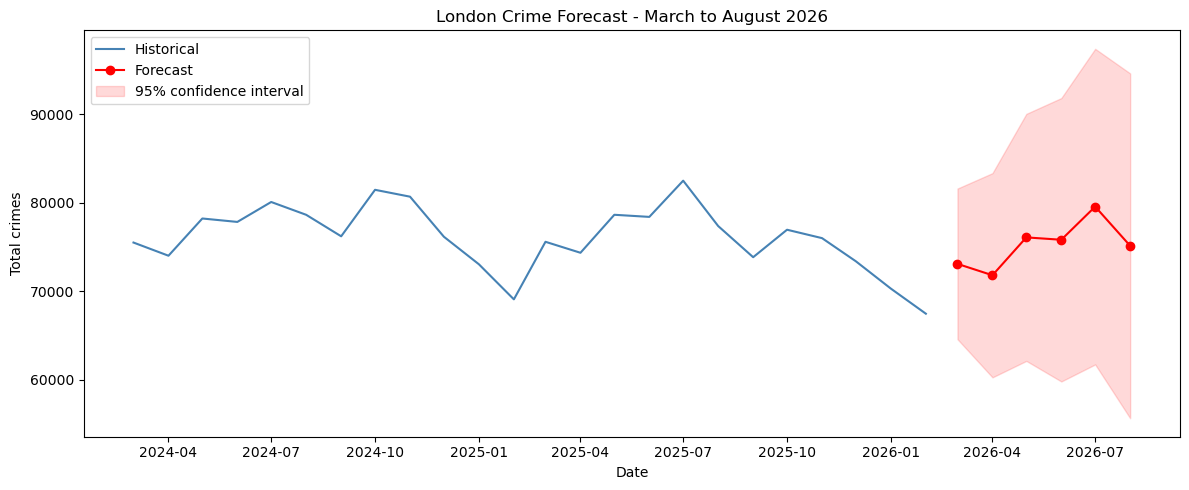

In [4]:
plt.figure(figsize=(12, 5))

recent_history = london_monthly[-24:]
plt.plot(recent_history.index, recent_history.values, label="Historical", color="steelblue")

plt.plot(future_forecast.index, future_forecast.values, label="Forecast", color="red", marker="o")

plt.fill_between(future_forecast.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                  color="red", alpha=0.15, label="95% confidence interval")

plt.title("London Crime Forecast - March to August 2026")
plt.xlabel("Date")
plt.ylabel("Total crimes")
plt.legend()
plt.tight_layout()
plt.savefig("figures/12_future_forecast.png", dpi=150)
plt.show()

In [5]:
from sklearn.ensemble import RandomForestClassifier

borough_monthly = (
    crime.groupby(["Borough", "Date"])["CrimeCount"]
    .sum()
    .reset_index()
    .rename(columns={"CrimeCount": "TotalCrimes"})
    .sort_values(["Borough", "Date"])
)

borough_avg = borough_monthly.groupby("Borough")["TotalCrimes"].transform("mean")
borough_monthly["CrimeDensity"] = borough_monthly["TotalCrimes"] / borough_avg
borough_monthly["Crimes_Lag1"] = borough_monthly.groupby("Borough")["TotalCrimes"].shift(1)
borough_monthly["Crimes_Lag12"] = borough_monthly.groupby("Borough")["TotalCrimes"].shift(12)
borough_monthly["Crimes_RollingMean3"] = (
    borough_monthly.groupby("Borough")["TotalCrimes"].shift(1).rolling(3).mean()
    .reset_index(level=0, drop=True)
)
borough_monthly = borough_monthly.dropna(subset=["Crimes_Lag1", "Crimes_Lag12", "Crimes_RollingMean3"])
borough_monthly["RiskLevel"] = pd.qcut(borough_monthly["CrimeDensity"], q=3, labels=["Low", "Medium", "High"])

feature_cols = ["Crimes_Lag1", "Crimes_Lag12", "Crimes_RollingMean3"]
final_forest = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
final_forest.fit(borough_monthly[feature_cols], borough_monthly["RiskLevel"])

print("Model trained on full history")
print("Last known month per borough:")
print(borough_monthly.groupby("Borough")["Date"].max().head())

Model trained on full history
Last known month per borough:
Borough
Barking and Dagenham   2026-02-01
Barnet                 2026-02-01
Bexley                 2026-02-01
Brent                  2026-02-01
Bromley                2026-02-01
Name: Date, dtype: datetime64[ns]


In [6]:
latest = borough_monthly.sort_values("Date").groupby("Borough").tail(1).copy()


next_month_features = pd.DataFrame({
    "Borough": latest["Borough"].values,
    "Crimes_Lag1": latest["TotalCrimes"].values,
    "Crimes_Lag12": latest["Crimes_Lag1"].values,   
})

next_month_rows = []
for borough in borough_monthly["Borough"].unique():
    b_data = borough_monthly[borough_monthly["Borough"] == borough].sort_values("Date")
    last_row = b_data.iloc[-1]
    lag1_next = last_row["TotalCrimes"]
    lag12_next = b_data.iloc[-12]["TotalCrimes"] if len(b_data) >= 12 else None
    rolling_next = b_data["TotalCrimes"].tail(3).mean()

    next_month_rows.append({
        "Borough": borough,
        "Crimes_Lag1": lag1_next,
        "Crimes_Lag12": lag12_next,
        "Crimes_RollingMean3": rolling_next
    })

next_month_df = pd.DataFrame(next_month_rows)
print(next_month_df.head())

                Borough  Crimes_Lag1  Crimes_Lag12  Crimes_RollingMean3
0  Barking and Dagenham         1447          1752          1545.666667
1                Barnet         2428          2435          2418.666667
2                Bexley         1170          1378          1243.000000
3                 Brent         2428          2693          2447.666667
4               Bromley         1829          1962          1833.333333


In [7]:
predictions = final_forest.predict(next_month_df[feature_cols])
prediction_probs = final_forest.predict_proba(next_month_df[feature_cols])

next_month_df["PredictedRisk"] = predictions

next_month_df["Confidence"] = prediction_probs.max(axis=1).round(2)

next_month_df = next_month_df.sort_values("PredictedRisk")
print(next_month_df[["Borough", "PredictedRisk", "Confidence"]].to_string(index=False))

               Borough PredictedRisk  Confidence
            Hillingdon          High        0.44
         Tower Hamlets          High        0.45
             Southwark          High        0.59
                Newham          High        0.88
              Lewisham          High        0.41
               Lambeth          High        0.46
             Islington          High        0.38
                Harrow          High        0.39
               Hackney          High        0.42
           Westminster          High        0.65
               Enfield          High        0.39
                Barnet          High        0.44
                Bexley          High        0.36
                 Brent          High        0.43
               Croydon          High        0.44
                Camden          High        0.60
                Ealing          High        0.45
              Hounslow           Low        0.38
              Havering           Low        0.45
Kensington and Chels

In [8]:
next_month_df.to_csv("data/future_risk_predictions.csv", index=False)
print("Saved!")

Saved!
